<a href="https://colab.research.google.com/github/srikarreddy213/Deep_Learning/blob/main/Road_Damage_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import kagglehub
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Path to dataset files: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [23]:
import os
print("Dataset structure:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Streaming output truncated to the last 5000 lines.
            vlcsnap-2025-02-18-23h12m22s604.txt
            vlcsnap-2025-02-19-16h22m29s339.txt
            vlcsnap-2025-02-18-23h25m48s850.txt
            vlcsnap-2025-02-19-14h42m40s085.txt
            vlcsnap-2025-02-18-18h35m43s212.txt
            vlcsnap-2025-02-19-16h24m19s410.txt
            vlcsnap-2025-02-26-20h42m08s749.txt
            vlcsnap-2025-02-19-14h49m38s907.txt
            vlcsnap-00062.txt
            vlcsnap-2025-02-19-17h02m53s135.txt
            vlcsnap-2025-02-18-18h45m09s626.txt
            vlcsnap-2025-02-19-14h30m24s704.txt
            vlcsnap_2025-03-16-15h18m28s053.txt
            vlcsnap-2025-02-19-15h05m48s501.txt
            vlcsnap-2025-02-18-17h03m26s001.txt
            vlcsnap-2025-02-18-18h32m48s578.txt
            vlcsnap-2025-02-18-23h29m08s868.txt
            vlcsnap_2025-03-16-15h24m09s426.txt
            vlcsnap-2025-02-18-18h32m56s495.txt
            vlcsnap-2025-02-19-14h29m46s948.txt
       

Total number of classes: 3
Class distribution:
- Class_0: 1261 instances
- Class_1: 2519 instances
- Class_2: 957 instances

Sample image dimensions (Width x Height): 640 x 360


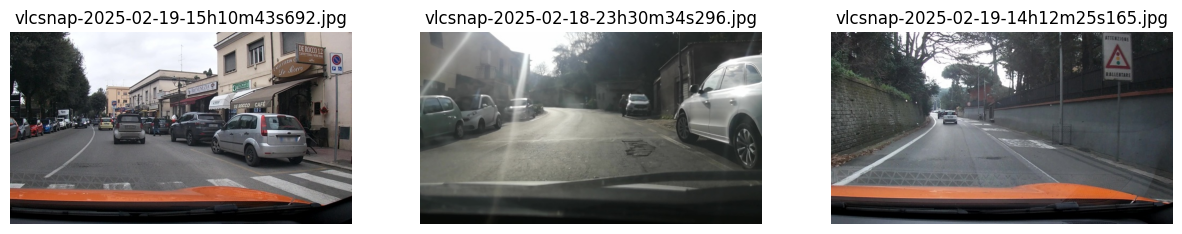

In [24]:
import os
import glob
from PIL import Image
from collections import defaultdict
import numpy as np
dataset_path = path
images_path = os.path.join(dataset_path, 'data', 'images')
labels_path = os.path.join(dataset_path, 'data', 'labels-YOLO')
class_counts = defaultdict(int)
class_names = {}
classes_txt_path = os.path.join(dataset_path, 'data', 'classes.txt')
if os.path.exists(classes_txt_path):
    with open(classes_txt_path, 'r') as f:
        for i, line in enumerate(f):
            class_names[i] = line.strip()
label_files = glob.glob(os.path.join(labels_path, '*.txt'))
for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_counts[class_id] += 1
if not class_names:
    for class_id in class_counts.keys():
        class_names[class_id] = f'Class_{class_id}'
print(f"Total number of classes: {len(class_names)}")
print("Class distribution:")
for class_id in sorted(class_counts.keys()):
    name = class_names.get(class_id, f'Unknown Class ({class_id})')
    print(f"- {name}: {class_counts[class_id]} instances")
image_files = glob.glob(os.path.join(images_path, '*.jpg'))
if image_files:
    sample_image_path = image_files[0]
    with Image.open(sample_image_path) as img:
        width, height = img.size
        print(f"\nSample image dimensions (Width x Height): {width} x {height}")
    import matplotlib.pyplot as plt
    plt.figure(figsize=(15, 5))
    for i in range(min(3, len(image_files))):
        img_path = image_files[i]
        with Image.open(img_path) as img:
            plt.subplot(1, 3, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path))
            plt.axis('off')
    plt.show()

In [25]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
IMG_SIZE = 224
def load_data(images_path, labels_path):
    images = []
    labels = []
    image_files = sorted(glob.glob(os.path.join(images_path, '*.jpg')))
    for img_path in image_files:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        base_name = os.path.basename(img_path).replace('.jpg', '.txt')
        label_file = os.path.join(labels_path, base_name)
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                line = f.readline().strip()
                if line:
                    class_id = int(line.split()[0])
                    images.append(img)
                    labels.append(class_id)
    return np.array(images), np.array(labels)
print("Loading and preprocessing images...")
X, y = load_data(images_path, labels_path)
X = X.astype('float32') / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)
print(f"Data loaded successfully!")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Loading and preprocessing images...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2052/3966083351.py", line 25, in <cell line: 0>
    X, y = load_data(images_path, labels_path)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2052/3966083351.py", line 17, in load_data
    with open(label_file, 'r') as f:
         ^^^^^^^^^^^^^^^^^^^^^
  File "<frozen codecs>", line 309, in __init__
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

T

TypeError: object of type 'NoneType' has no len()

### Task 3: Data Augmentation
Data augmentation is crucial for CNNs to:
1. Increase the effective size of the training dataset.
2. Prevent overfitting by exposing the model to variations of the same image.
3. Improve generalization so the model works well on real-world, unseen data.

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)
datagen.fit(X_train)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,339 (84.86 MB)

 Trainable params: 22,245,891 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
EPOCHS = 20
BATCH_SIZE = 32
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_cat),
    epochs=EPOCHS
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 46s 703ms/step - accuracy: 0.3827 - loss: 16.2472 - val_accuracy: 0.4627 - val_loss: 12.7192
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 0.4375 - loss: 10.5130 - val_accuracy: 0.5000 - val_loss: 23.8151
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 444ms/step - accuracy: 0.4231 - loss: 4.4846 - val_accuracy: 0.5000 - val_loss: 53.1098
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 420ms/step - accuracy: 0.4686 - loss: 5.1976 - val_accuracy: 0.4975 - val_loss: 49.3489
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 455ms/step - accuracy: 0.4748 - loss: 2.6963 - val_accuracy: 0.4478 - val_loss: 39.1143
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 442ms/step - accuracy: 0.4680 - loss: 2.1194 - val_accuracy: 0.4975 - val_loss: 74.1921
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 446ms/step - accuracy: 0.4823 - loss: 1.3648 - val_accuracy: 0.4826 - val_loss: 71.0901
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 448ms/step - accuracy: 0.4872 - loss: 1.4271 -

Evaluating model performance...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.50      0.97      0.66       201
           2       0.17      0.02      0.03       108

    accuracy                           0.49       402
   macro avg       0.22      0.33      0.23       402
weighted avg       0.29      0.49      0.34       402

Confusion Matrix:


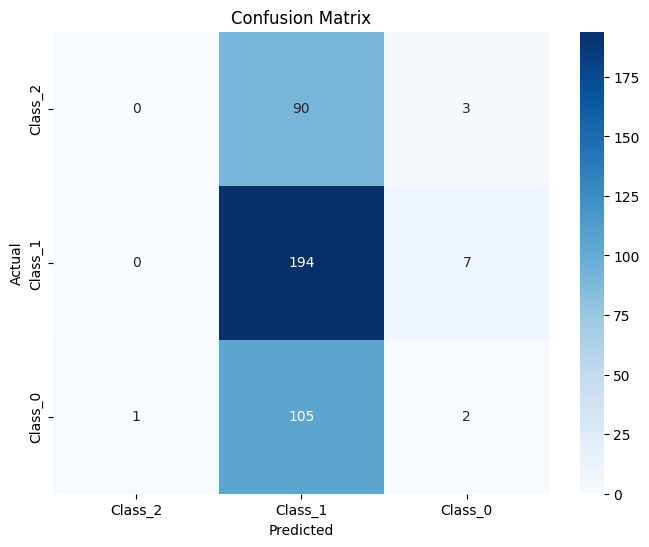

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Evaluating model performance...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names.values(), yticklabels=class_names.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Total misclassified images: 206


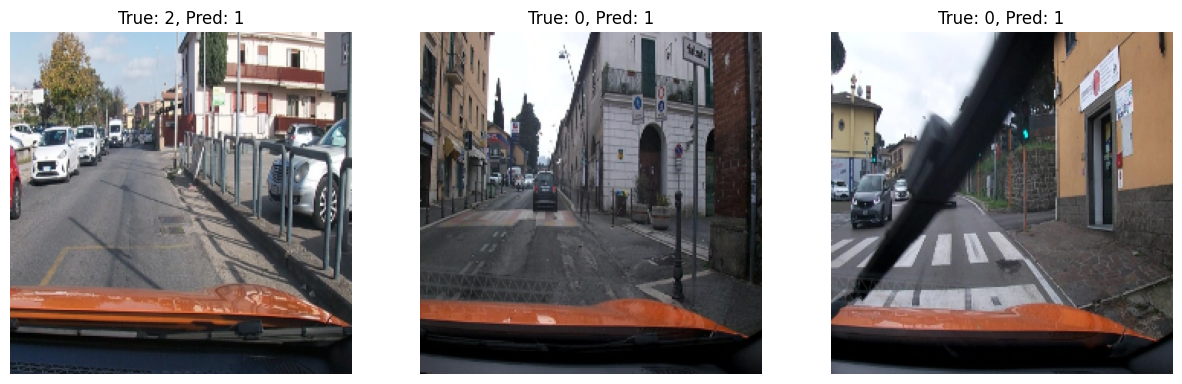

In [19]:
misclassified_indices = np.where(y_pred_classes != y_test)[0]
print(f"Total misclassified images: {len(misclassified_indices)}")
if len(misclassified_indices) > 0:
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(misclassified_indices[:3]):
        plt.subplot(1, 3, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"True: {y_test[idx]}, Pred: {y_pred_classes[idx]}")
        plt.axis('off')
    plt.show()
else:
    print("No misclassifications found on the test set.")

In [20]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized.astype('float32') / 255.0
    img_expanded = np.expand_dims(img_normalized, axis=0)
    prediction = model.predict(img_expanded)
    predicted_class = np.argmax(prediction)
    return class_names[predicted_class], prediction[0][predicted_class]
test_sample = image_files[0]
label, score = predict_image(test_sample)
print(f"Predicted Class: {label} (Confidence: {score:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class: Class_1 (Confidence: 0.48)


In [27]:
import json
model.save('road_damage_model.h5')
model.save_weights('road_damage_weights.weights.h5')
with open('label_mappings.json', 'w') as f:
    json.dump(class_names, f)
print("Model, weights, and labels exported successfully!")

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7eb918f2cd60>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 


Model, weights, and labels exported successfully!


In [26]:
import pandas as pd
test_image_files = sorted(glob.glob(os.path.join(images_path, '*.jpg')))[-len(y_test):]
results_df = pd.DataFrame({
    'image_path': test_image_files,
    'actual_class': y_test,
    'predicted_class': y_pred_classes,
    'actual_label': [class_names[c] for c in y_test],
    'predicted_label': [class_names[c] for c in y_pred_classes]
})
results_df.to_csv('road_damage_results.csv', index=False)
display(results_df.head())

,image_path,actual_class,predicted_class,actual_label,predicted_label
0,/kaggle/input/road-damage-dataset-potholes-cra...,2,1,Class_2,Class_1
1,/kaggle/input/road-damage-dataset-potholes-cra...,0,1,Class_0,Class_1
2,/kaggle/input/road-damage-dataset-potholes-cra...,0,1,Class_0,Class_1
3,/kaggle/input/road-damage-dataset-potholes-cra...,1,1,Class_1,Class_1
4,/kaggle/input/road-damage-dataset-potholes-cra...,1,1,Class_1,Class_1
